# Circuitos Eletrônicos I - T3
## Lista para a Prova

### Autor: João Victor Colombari Carlet

Neste notebook vamos analisar os circuitos propostos na lista de exercícios para a prova final.

### Ferramentas Utilizadas:
* **`ngspice`**: Nosso motor de simulação de backend, encarregado de resolver as equações matriciais não-lineares dos diodos.
* **`PySpice`**: A biblioteca de ponte que traduz comandos do Python para comandos interpretados pelo SPICE.


## Passo 0: Inicializando o Ambiente de Simulação e Gráficos


Vamos verificar se as ferramentas do `matplotlib` para gerar curvas de alta resolução, o leitor de arquivos (`SpiceParser`) do `PySpice`, e o numpy estão instalados e depois importar tudo.

> **Importante:** Para executar as simulações localmente, vocês vão precisar do ngspice instalado. Pelo OSX é só executar: 

```bash
brew install ngspice
```

No Linux:

```bash
sudo apt-get update
sudo apt-get install ngspice
```

No windows fico devendo, mas não deve ser dificil.. 

In [1]:
import sys
print(f"Ambiente ativo: {sys.executable}")

# Instalação silenciosa das dependências necessárias no kernel atual
!{sys.executable} -m pip -q install numpy matplotlib pyspice schemdraw

Ambiente ativo: /Users/joaovitor/Documents/PhD/PAE/eletronicos_I/prova/venv/bin/python

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from PySpice.Spice.Parser import SpiceParser
from PySpice.Unit import *
import numpy as np

print("Bibliotecas prontas para simulação.")

Bibliotecas prontas para simulação.


---
# Exercício 1: Diagrama de bandas e alguns problemas teóricos do bipolar

1 - Desenhe os níveis de energia (EC, EV, Ei e EF) e densidade de portadores para um transistor NPN polarizado diretamente (Vbe > 0,6 V; Vbc < 0V).

2 - Desenhe os níveis de energia (EC, EV, Ei e EF) e densidade de portadores para um transistor PNP polarizado diretamente (Vbe < - 0,6 V; Vbc > 0V).

3 - O que causa o efeito Early (fisicamente)?

4 - Por que em um transistor bipolar é bom que a concentração de impurezas na base seja maior do que a concentração no coletor?

5 - Considere agora dois diodos NP ligados de forma semelhante a um transistor bipolar (Figura 1). Refazer os itens 1.1 e 1.2.  

---

#### Para desenhar os diagramas é que nem na lista 2. Desenha separadamente cada porção de silicio alinhando os níveis de fermi (mais ou menos o deslocamento $q|V|$ da polarização) e depois conecta $E_V$, $E_i$ e $E_C$.

No caso do transistor, a largura da base $W_B$ é pequena e a dopagem da base é menor que a do emissor, isso faz com que haja pouca recombinação e que a corrente de elétrons seja maior que a de lacunas na base, o que muda o diagrama de densidade de portadores entre transistor e diodos conectados. 

O diagrama de bandas do NPN é o seguinte:

<p align="center">
    <img src="figuras/f1.png" width="800">
</p>

E o diagrama de densidade de portadores:

<p align="center">
    <img src="figuras/f2.png" width="800">
</p>

Enquanto que nos diodos fica da seguinte forma:

<p align="center">
    <img src="figuras/f3.png" width="800">
</p>

Para a prova, se pedido como no item 1.5 mostrem a distinção do $W_B$ e o comportamento a concentração de portadores na base. 

Para o PNP o comportamento é análogo, mudando a direção das coisas. Preservem a ordem dos terminais para facilitar a comparação entre os dois. 

#### O Efeito Early 

Esse é o efeito que faz com que o transistor não seja uma fonte de corrente controlada por tensão ideal, mostrando uma inclinação na família de curvas. 

Ele é causado pela diminuição da largura efetiva da base do transistor $W_{Bef}$. Quando a tensão reversa aumenta, a região de depleção aumenta e isso acarreta no aumento de $W_{Bef}$, o que aumenta a corrente. 

#### As impurezas no coletor 

Vai meio na linha do que acontece com o Early. Se $W_{Bef}$ diminui, é bom controlar esse fenomeno. Se a dopagem no coletor fosse muito alta, a região de depleção entre base e coletor iria entrar na emissor base, o que não é legal. 

Rule of thumb é então 

$$
    N_{DE} >> N_A > N_{DC}
$$

---
# Exercício 2: Sedra

Neste recorram ao solucionário do Sedra. Em caso de dúvida me enviem um email.
---

---
# Exercício 3: Push-Pull/Inversos

Neste exercício, vamos analizar um circuito Push-Pull/Inversos, que é extremamente usado. 
---

#### Análise rápida do circuito

Nesse ou um ou outro conduz, sendo que de $-0.7$ a $0.7V$ ambos estão em corte. Quando a entrada é menor que $-0.7V$, $V_{BE}$ do transistor de baixo é meior que o limiar, então o transistor PNP puxa (pull) corrente, enquanto que o NPN fica cortado. Para o oposto, o NPN empurra (push) corrente, o que da o comportamento do circuito. 

A tensão de saída segue a entrada de maneira linear a menos de $|0.7|V$ até que sature.

Nesse exercicio tem um pulo do gato que é o resistor das bases, então precisamos considerar essa queda na entrada. 

Com $V_{BE}=0,7,V$:

$$
V_O = V_B - 0,7
$$

A corrente na carga é

$$
I_L=\frac{V_O}{R_L}
$$

Como a corrente de emissor é a corrente da carga (pq os transistores operam intermitentemente),

$$
I_E=I_L
$$

e

$$
I_E=(\beta+1)I_B
$$

Se tem que:

$$
\frac{V_O}{R_L(\beta+1)}
$$

Por outro lado, a corrente na resistência de base é

$$
I_B=\frac{V_{in}-V_B}{R_B}
$$

Substituindo $V_B=V_O+0,7$:

$$
\frac{V_O}{R_L(\beta+1)}
$$

Com

$$
V_{in}=5V,\quad
R_B=10k\Omega,\quad
R_L=1k\Omega,\quad
\beta=100
$$

resulta

$$
\frac{V_O}{101000}
$$

Resolvendo:

$$
101(4,3-V_O)=10V_O
$$

$$
434,3=111V_O
$$

$$
V_O=3,91V
$$

Logo,

$$
I_L=\frac{3,91}{1000}
=3,91,mA
$$


Node name 'in' is a Python keyword
Unsupported Ngspice version 46


Simulação do Circuito concluída com sucesso.


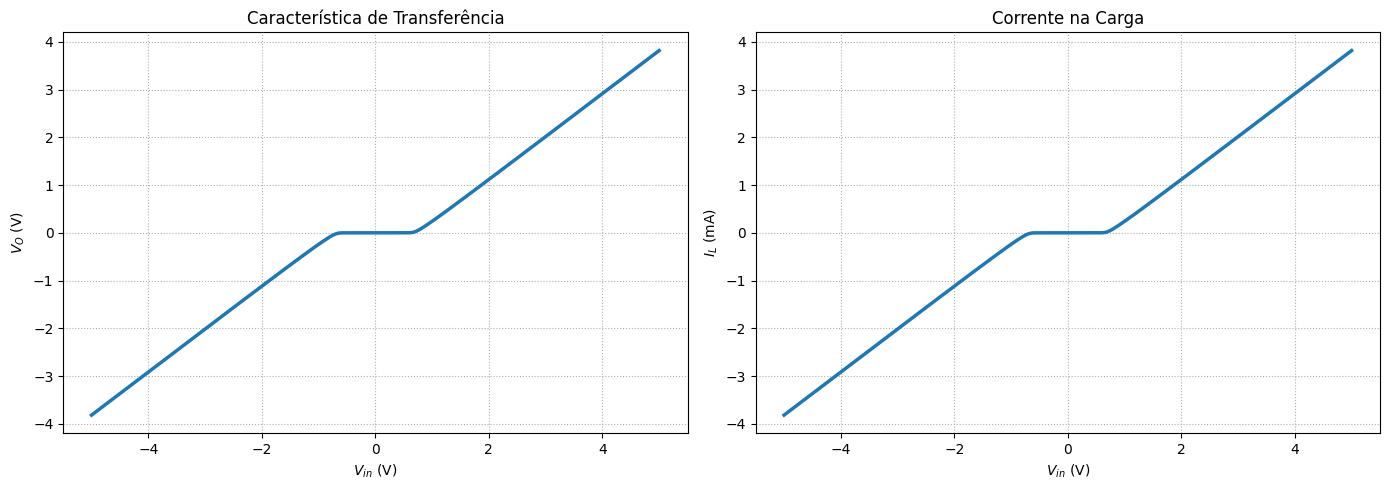

In [4]:
# 1. Carrega o arquivo de netlist exportado do LTspice
analysis = SpiceParser(path='netlists/q3/circuit.net').build_circuit().simulator().dc(V1=slice(-5, 5, 0.05))

print("Simulação do Circuito concluída com sucesso.")

# Tensões
vin = np.array(analysis.sweep)
vo = np.array(analysis['n002'])

# Corrente na carga
RL = 1000
il = vo / RL * 1000  # mA

# Plotagem
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(vin, vo, linewidth=2.5)
axs[0].set_title('Característica de Transferência')
axs[0].set_xlabel('$V_{in}$ (V)')
axs[0].set_ylabel('$V_O$ (V)')
axs[0].grid(True, linestyle=':')

axs[1].plot(vin, il, linewidth=2.5)
axs[1].set_title('Corrente na Carga')
axs[1].set_xlabel('$V_{in}$ (V)')
axs[1].set_ylabel('$I_L$ (mA)')
axs[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

---
# Exercício 3: Push-Pull/Inversos

Neste exercício, vamos analizar um circuito emissor comum com bypass (não degenerado). Esse é um circuito que tudo tem que estar na ponta da lingua. 

Uma vez fiz uma entrevista de emprego e o cara literalmente me perguntou o ganho disso.. 
---

#### Análise rápida do circuito

Aqui vamos dar uma olhada no circuito a pequenos sinais. Peguei uma análise nos slides, então desconsidere os valores:

<p align="center">
    <img src="figuras/f4.png" width="800">
</p>

Fica claro que o ganho vai ser a resistencia na saída vezesa transcondutancia, o que é verdade quase sempre, seja para válvula, bipolar, JFET ou MOS. 

Aqui vou considerar $r_0$, mas faz as contas aí para ver que a diferença é pequena (porque?):

#### 1. Determinação de $R_C$ e $I_C$ para Ganho $A_v = -40$ e $V_C = 4,0\text{ V}$

O ganho de tensão a pequenos sinais é:
$$A_v = -g_m \cdot (r_0 \parallel R_C \parallel R_L)$$

Substituindo $g_m = \frac{I_C}{V_T}$ e abrindo o paralelo de saída, temos:
$$A_v = -\frac{I_C}{V_T} \cdot \left( \frac{1}{\frac{1}{r_0} + \frac{1}{R_C} + \frac{1}{R_L}} \right)$$

Como $r_0 = \frac{V_{AF}}{I_C}$, podemos substituir $\frac{1}{r_0}$ por $\frac{I_C}{V_{AF}}$:
$$A_v = -\frac{I_C}{V_T} \cdot \left( \frac{1}{\frac{I_C}{V_{AF}} + \frac{1}{R_C} + \frac{1}{R_L}} \right)$$

Pela malha de saída em corrente contínua (CC), mantemos a relação:
$$V_C = V_{DD} - R_C \cdot I_C \implies 4,0 = 6,0 - R_C \cdot I_C \implies R_C = \frac{2,0}{I_C}$$

Substituindo $\frac{1}{R_C} = \frac{I_C}{2,0}$ e os valores conhecidos ($A_v = -40$, $V_T = 0,02586\text{ V}$, $V_{AF} = 100\text{ V}$ e $R_L = 1000\text{ }\Omega$) na equação do ganho:
$$40 = \frac{I_C}{0,02586} \cdot \left( \frac{1}{\frac{I_C}{100} + \frac{I_C}{2,0} + \frac{1}{1000}} \right)$$

Colocando $I_C$ em evidência no denominador para simplificar com o numerador:
$$40 = \frac{I_C}{0,02586} \cdot \left( \frac{1}{I_C \cdot \left( \frac{1}{100} + \frac{1}{2,0} \right) + 0,001} \right)$$

$$\implies I_C = \frac{0,04}{18,27} \approx 0,00219\text{ A} = \mathbf{2,19\text{ mA}}$$

Agora, isolando e determinando o valor exato necessário para $R_C$:
$$R_C = \frac{2,0\text{ V}}{2,19\text{ mA}} \approx \mathbf{913\text{ }\Omega}$$

### 2. Faixa de Valores para Polarização de $V_b$ e Melhor Valor

A saída $V_o$ está acoplada no nó do coletor ($V_C$). Para uma excursão simétrica de $\pm 1,0\text{ V}$, a tensão $V_C$ oscila entre $3,0\text{ V}$ e $5,0\text{ V}$.

**1 - Não saturar:** No pior caso ($V_{C,min} = 3,0\text{ V}$), precisa garantir que $V_{CE} > V_{CE,sat} \approx 0,2\text{ V}$.
    $$V_{C,min} - V_E > 0,2 \implies 3,0 - (V_b - 0,7) > 0,2 \implies V_b < 3,5\text{ V}$$

**2 - Não cortar:** a junção base-emissor deve permanecer diretamente polarizada ($V_b > 0,7\text{ V}$).

**Faixa permitida:** $0,7\text{ V} < V_b < 3,5\text{ V}$.

**Melhor Valor:** **$V_b = 2,0\text{ V}$**. 
Com a tensão de emissor em $V_E = 1,3\text{ V}$, a tensão $V_{CE}$ fica estável em $2,7\text{ V}$ no ponto de operação, mantendo o transistor na Região Ativa com margem contra a saturação ($V_{CE,min} = 3,0 - 1,3 = 1,7\text{ V} \gg 0,2\text{ V}$).

#### 3. $V_b$ = 2,0 V. Determine os valores de $R_E$, $R_{b1}$ e $R_{b2}$

Aqui é só descontar o $V_{BE}$ e calcular $R_E$:

$$V_E = V_b - V_{BE} = 2,0 - 0,7 = 1,3\text{ V}$$

Como $I_E \approx I_C = 2,19\text{ mA}$:

$$R_E = \frac{V_E}{I_E} = \frac{1,3\text{ V}}{2\text{ mA}} = \mathbf{593.61\text{ }\Omega}$$

Para um divisor de tensão firme/estável, dimensionamos a corrente do divisor para ser aproximadamente $10$ vezes maior que a corrente de base do transistor ($I_B = I_C/\beta = 2\text{ mA}/100 = 20\text{ }\mu\text{A}$). Outra coisa legal de fazer é evitar valor muito grande de resistor. No mundo real isso tem muita indutancia, o que pode dar uma zuada em circuito com subidas e descidas muito rapidas (ringing).

$$R_{Th} \approx 0,1 \cdot \beta \cdot R_E = 0,1 \cdot 100 \cdot 593.61 = 5,9\text{ k}\Omega$$
    
Pela equação do divisor de tensão para obter $V_b = 2\text{ V}$ a partir de $V_{DD} = 6\text{ V}$:
$$\frac{R_{b1}}{R_{b1} + R_{b2}} \cdot 6 = 2 \implies R_{b2} = 2 \cdot R_{b1}$$
    
Substituindo na resistência de Thevenin ($R_{Th} = R_{b1} \parallel R_{b2}$):
$$\frac{R_{b1} \cdot 2R_{b1}}{R_{b1} + 2R_{b1}} = 5,9\text{ k} \implies \frac{2}{3}R_{b1} = 6,5\text{ k} \implies R_{b1} = 8,85\text{ k}\Omega$$

$$ \implies \mathbf{R_{b2} = 2 \cdot R_{b1} \approx 17,7\text{ k}\Omega}$$

#### 4. Impedâncias de Entrada ($Z_{in}$) e Saída ($Z_{out}$)

* **Impedância de Entrada ($Z_{in}$):**
    Com o emissor aterrado pelo capacitor $C_E$ para sinais CA, a impedância vista pela base é $r_\pi$:
    $$r_\pi = \frac{\beta \cdot V_T}{I_C} = \frac{100 \cdot 25\text{ mV}}{2\text{ mA}} = 1250\text{ }\Omega = 1,25\text{ k}\Omega$$
    $$Z_{in} = R_{b1} \parallel R_{b2} \parallel r_\pi = 8,85\text{ k} \parallel 17,7\text{ k} \parallel 1,25\text{ k} \approx \mathbf{1,03\text{ k}\Omega}$$

Se tiver sem tempo para calcular fala que vai ficar proxima de $r_\pi$

* **Impedância de Saída ($Z_{out}$):**
    Desconsiderando a carga externa $R_L$:
    $$Z_{out} = R_C|| = 1,0\text{ k}\Omega||1,0\text{ k}\Omega \approx 895,10 \Omega$$